In [ ]:
import marimo as mo

> **Generated file.** This notebook is exported from its marimo source
> src/pipelines/04_eda_annot_gt_cycle/02_synthetic_shelly_cycle_eda.py.
> Edit the source and re-export; do not edit the exported notebook by hand.

# Synthetic-Shelly cycle EDA: are the marks correct, and do they predict?

Same question as the UK-DALE GT-cycle EDA - **if we have marks "this
device ran here", can we (a) tell which device it was and (b) turn the
mark into a profile that predicts its cycles from the aggregate alone?**
- run here on the client's **synthetic Shelly dataset** (30 days at 5 s,
4 labelled appliances, read-only under repo/). This dataset has no human
marks: the *_on flags are the generator's own state variables, i.e.
**machine-perfect cycle annotations** - so no manual curation is
performed, and the run is an *idealized upper bound*, not a product
claim. Shape/cadence facts were first established by the client-repo
forensics (deprecated/analysis/repo-forensics/); this notebook recomputes what it
uses. All numbers are provisional until margins freeze; nothing below
is a gate.

In [ ]:
# Headless rendering (export runs without a display) + shared baseline
# lib. baseline_lib lives with the 00_baseline experiment; the path is
# resolved relative to this file so the notebook stays relocatable.
import sys
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
_here = Path(__file__).resolve()
sys.path.insert(0, str(_here.parents[2] / "experiments" / "00_baseline"))
import baseline_lib as bl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# --- Notebook parameters (provisional, stated up front) ---------------
# Timestamps: int64 UTC microseconds; durations in seconds; power in W.
# The synthetic CSV timestamps are naive; they are treated as UTC (the
# generator's diurnal template is aligned with them either way).
cfg = {
    "dataset": "synthetic_shelly",
    "source_csv": "repo/WattWiser/data/raw/synthetic_shelly_data.csv",
    "cadence_s": 5.0,
    "split_days": 15.0,  # first 15 d calibration / last 15 d test
    "smooth_samples": 5,  # centered mean at the 5 s cadence (25 s)
    "base_win_samples": 120,  # trailing 10 min local-baseline window
    "hys_on_w": 500.0,  # run starts when detrended mains crosses this
    "hys_off_w": 200.0,  # ... ends after this many samples below
    "hys_release": 3,
    "det_thr_frac": 0.6,  # qualifying activation: dP >= 0.6 x profile dP
    "band_hi_frac": 1.5,  # band-gate variant upper bound (burst devices)
    "det_dur_lo": 0.5,  # candidate dur >= 0.5 x profile dur
    "det_dur_hi": 2.0,  # candidate dur <= 2.0 x profile dur
    "chain_gap_s": 1800.0,  # program-device chaining gap clamp
    "anchor_band_hi_frac": 1.2,  # anchored variant upper band (WM only)
    "anchor_pre_frac": 0.25,  # anchored window starts this x dur early
    "anchor_merge_frac": 0.5,  # anchored window merge overlap threshold
    "ov_min_s": 60.0,  # cycle match: >= 60 s overlap with the marks
    "ov_frac": 0.3,  # ... or >= 30% of the mark span, whichever smaller
    "program": ["washing_machine"],
    "burst": ["kettle", "microwave"],
    "duty": ["fridge"],  # compressor duty cycle: excluded from the
    # cycle-mark flow (same treatment as the UK-DALE EDA); still shown
    # as a profile row for reference.
}

In [ ]:
# presentation: parameters table
mo.md("## Parameters used in this EDA\n\n" + bl.md_table(["parameter", "value"], [[k, v] for k, v in cfg.items()]))

## Parameters used in this EDA

| parameter | value |
|---|---|
| dataset | synthetic_shelly |
| source_csv | repo/WattWiser/data/raw/synthetic_shelly_data.csv |
| cadence_s | 5.0 |
| split_days | 15.0 |
| smooth_samples | 5 |
| base_win_samples | 120 |
| hys_on_w | 500.0 |
| hys_off_w | 200.0 |
| hys_release | 3 |
| det_thr_frac | 0.6 |
| band_hi_frac | 1.5 |
| det_dur_lo | 0.5 |
| det_dur_hi | 2.0 |
| chain_gap_s | 1800.0 |
| anchor_band_hi_frac | 1.2 |
| anchor_pre_frac | 0.25 |
| anchor_merge_frac | 0.5 |
| ov_min_s | 60.0 |
| ov_frac | 0.3 |
| program | ['washing_machine'] |
| burst | ['kettle', 'microwave'] |
| duty | ['fridge'] |

In [ ]:
# --- Load the synthetic dataset once (computation) ---------------------
# The CSV is the client's synthesized 30-day trace (read-only under
# repo/). Timestamps are naive; treated as UTC. Device channels are
# measured ground truth for scoring; every profile feature below is
# derived from the aggregate alone. The *_on flags are the marks (no
# manual curation in this EDA, per scope).
_path = Path(bl.ROOT) / cfg["source_csv"]
_df = pd.read_csv(_path)
_ts = pd.to_datetime(_df["timestamp"], format="%Y-%m-%d %H:%M:%S")
tsu = _ts.dt.tz_localize("UTC").astype("datetime64[us, UTC]").astype("int64").to_numpy()
w = _df["active_power_W"].to_numpy(float)
_names = cfg["program"] + cfg["burst"] + cfg["duty"]
ch = {n: _df[n + "_power_W"].to_numpy(float) for n in _names}
on_flags = {n: _df[n + "_on"].astype(bool).to_numpy() for n in _names}

def _episodes(flag):
    starts = np.flatnonzero(flag & ~np.r_[False, flag[:-1]])
    ends = np.flatnonzero(flag & ~np.r_[flag[1:], False])
    return [(int(tsu[s]), int(tsu[e])) for s, e in zip(starts, ends)]

marks = {n: _episodes(on_flags[n]) for n in _names}
split_us = int(tsu.min()) + int(cfg["split_days"] * 86_400_000_000)

In [ ]:
# --- Detrended aggregate (computation) ---------------------------------
# Runs are found on the detrended signal d = smoothed mains minus its
# trailing local mean: the synthetic base template sits at about 260 W,
# so a raw absolute-threshold hysteresis (as on UK-DALE's 40-60 W base)
# would never release. The detrending is aggregate-only: deployment
# honest, no channel knowledge.
sm = pd.Series(w).rolling(cfg["smooth_samples"], center=True, min_periods=1).mean().to_numpy()
_base10 = pd.Series(sm).rolling(cfg["base_win_samples"], min_periods=1).mean().to_numpy()
d = sm - _base10

In [ ]:
# --- Data health + additivity (computation: measured, not assumed) -----
_dt = np.diff(tsu) / 1e6
_cad = cfg["cadence_s"]
health = {
    "rows": int(tsu.size),
    "modal_dt_s": float(np.median(_dt)),
    "cadence_violations": int((np.abs(_dt - _cad) > 0.1).sum()),
    "span_days": float((tsu[-1] - tsu[0]) / 86_400_000_000),
}
# Additivity: base template = aggregate - sum of device channels; then
# the strongest check - every large step in the smoothed aggregate must
# be explained by the device channels (zero unlabelled loads).
_devsum = np.sum([ch[n] for n in sorted(ch)], axis=0)
_baset = w - _devsum
_devsm = pd.Series(_devsum).rolling(cfg["smooth_samples"], center=True, min_periods=1).mean().to_numpy()
_dsm = np.diff(sm)
_ddv = np.diff(_devsm)
_big = np.abs(_dsm) >= 100.0
additivity = {
    "base_mean_w": float(_baset.mean()),
    "base_p50_w": float(np.median(_baset)),
    "base_min_w": float(_baset.min()),
    "base_max_w": float(_baset.max()),
    "base_max_step_w": float(np.abs(np.diff(_baset)).max()),
    "n_big_steps": int(_big.sum()),
    "max_unexplained_step_w": float(np.abs(_dsm[_big] - _ddv[_big]).max()) if _big.any() else 0.0,
}

In [ ]:
# presentation: health + additivity tables
_h = bl.md_table(
    ["property", "value"],
    [
        ["rows", f"{health['rows']:,}"],
        ["modal cadence (s)", f"{health['modal_dt_s']:.1f}"],
        ["cadence violations", f"{health['cadence_violations']:,}"],
        ["span (days)", f"{health['span_days']:.2f}"],
    ],
)
_a = bl.md_table(
    ["additivity property", "value"],
    [
        ["base template mean (W)", f"{additivity['base_mean_w']:.1f}"],
        ["base template p50 (W)", f"{additivity['base_p50_w']:.1f}"],
        ["base template min / max (W)", f"{additivity['base_min_w']:.1f} / {additivity['base_max_w']:.1f}"],
        ["base template max 1-sample step (W)", f"{additivity['base_max_step_w']:.1f}"],
        ["aggregate steps >= 100 W (smoothed)", f"{additivity['n_big_steps']:,}"],
        ["max unexplained step (W)", f"{additivity['max_unexplained_step_w']:.2f}"],
    ],
)
mo.md(
    "## Data health (measured)\n\n"
    + _h
    + "\n\n## Additivity (measured)\n\n"
    + "The base template is whatever the aggregate retains after removing "
    + 'the four device channels - the "always-on" synthesis floor. The '
    + "decisive row is the last: the largest smoothed-aggregate step that "
    + "the device channels fail to explain.\n\n"
    + _a
)

## Data health (measured)

| property | value |
|---|---|
| rows | 518,400 |
| modal cadence (s) | 5.0 |
| cadence violations | 0 |
| span (days) | 30.00 |

## Additivity (measured)

The base template is whatever the aggregate retains after removing the four device channels - the "always-on" synthesis floor. The decisive row is the last: the largest smoothed-aggregate step that the device channels fail to explain.

| additivity property | value |
|---|---|
| base template mean (W) | 264.9 |
| base template p50 (W) | 258.9 |
| base template min / max (W) | 119.9 / 445.6 |
| base template max 1-sample step (W) | 124.5 |
| aggregate steps >= 100 W (smoothed) | 3,261 |
| max unexplained step (W) | 16.25 |

## Part A - look at a whole marked day first

Before any rule: the busiest washing-machine day, aggregate vs all four
device channels, with the WM marks shaded. On this dataset every device
is labelled at every sample, so the picture doubles as a correctness
eyeball: what the channel does inside its mark, and nothing outside it.

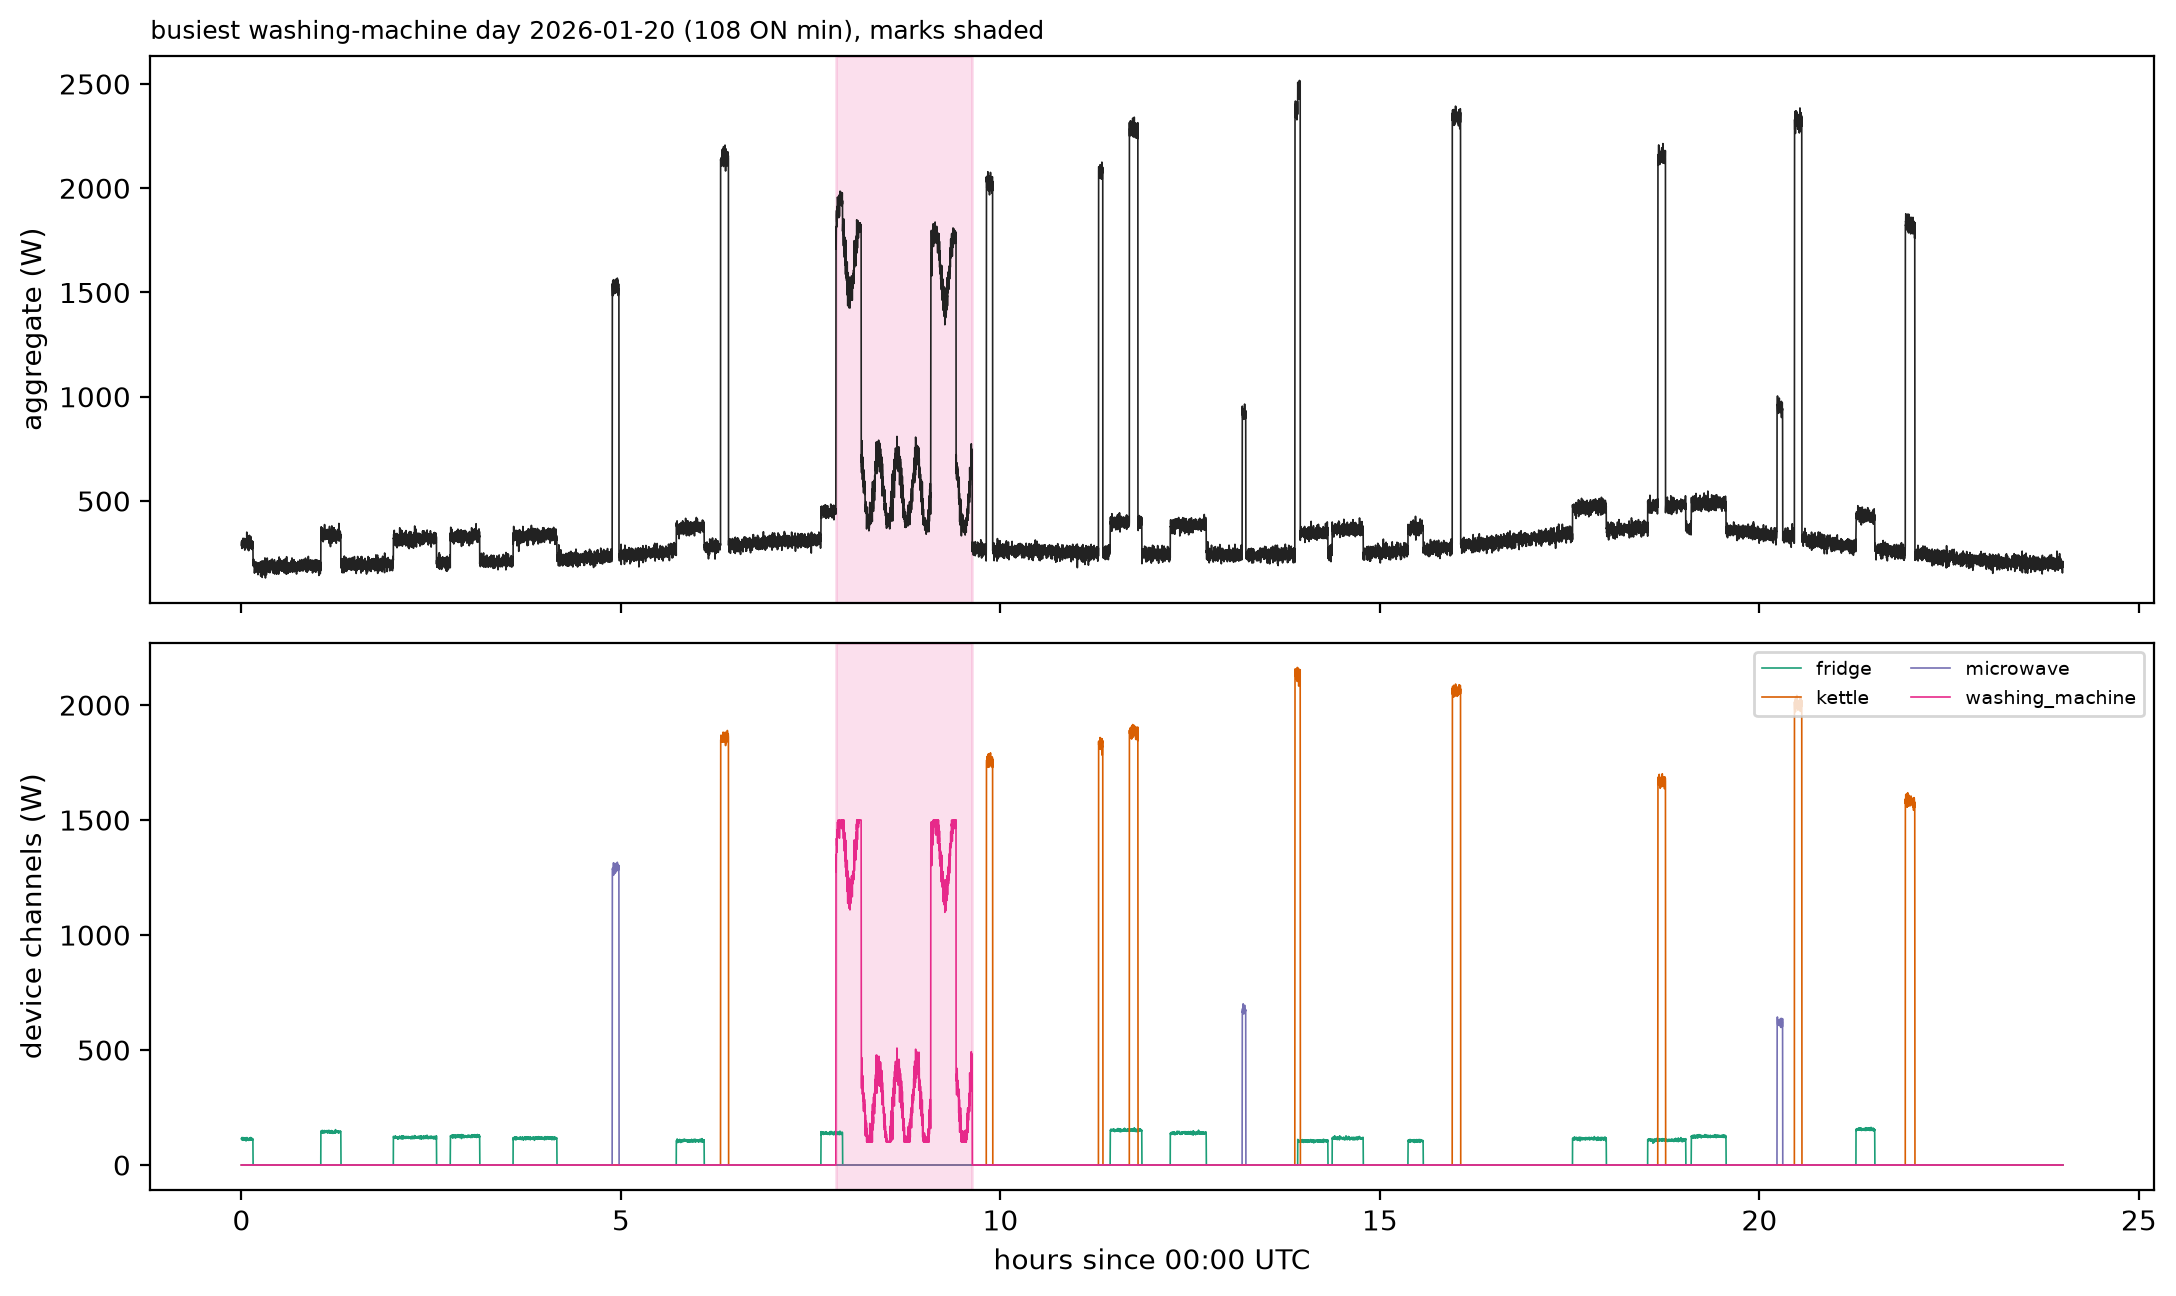

In [ ]:
# --- One marked day, raw overlay (computation + figure) ----------------
_cad = cfg["cadence_s"]
_wm_w = ch["washing_machine"]
_days = (tsu // 86_400_000_000).astype(np.int64)
_on_min = {}
for _d in np.unique(_days):
    _sel = _days == _d
    _on_min[int(_d)] = float(np.sum(_wm_w[_sel] > 0.0) * _cad / 60.0)
_ranked = sorted(_on_min, key=_on_min.get, reverse=True)
_busy = int(_ranked[0])
_lo, _hi = _busy * 86_400_000_000, (_busy + 1) * 86_400_000_000
_i0, _i1 = int(np.searchsorted(tsu, _lo)), int(np.searchsorted(tsu, _hi))
_hh = (tsu[_i0:_i1] - _lo) / 3.6e9
_colors = {
    "kettle": "#d95f02",
    "microwave": "#7570b3",
    "fridge": "#1b9e77",
    "washing_machine": "#e7298a",
}
fig_days, _axes = plt.subplots(2, 1, figsize=(11, 6.6), sharex=True)
_ax = _axes[0]
_ax.plot(_hh, w[_i0:_i1], color="#222222", lw=0.6)
_ax.set_ylabel("aggregate (W)")
_ax.set_title(
    f"busiest washing-machine day {pd.to_datetime(_lo, unit='us'):%Y-%m-%d}"
    + f" ({_on_min[_busy]:.0f} ON min), marks shaded",
    fontsize=9,
    loc="left",
)
_ax2 = _axes[1]
for _n in sorted(ch):
    _ax2.plot(_hh, ch[_n][_i0:_i1], color=_colors[_n], lw=0.6, label=_n)
_ax2.set_ylabel("device channels (W)")
_ax2.set_xlabel("hours since 00:00 UTC")
for _axx in _axes:
    for _a, _b in marks["washing_machine"]:
        if _b > _lo and _a < _hi:
            _axx.axvspan(
                (max(_a, _lo) - _lo) / 3.6e9,
                (min(_b, _hi) - _lo) / 3.6e9,
                color="#e7298a",
                alpha=0.15,
            )
_ax2.legend(fontsize=7, loc="upper right", ncols=2)
fig_days.tight_layout()
fig_days  # noqa: B018  (render figure as cell output)

Reading the day: the WM block rises out of the aggregate as one clear
multi-hundred-watt plateau; kettle and microwave spikes sit on top of a
quiet 260 W base; the fridge is a thin sawtooth. The marks cover exactly
what the channel does - nothing more, nothing less.

## Part B - are the annotations correct cycle marks?

Three checks, all recomputed here (nothing assumed from the forensics):
(1) **flag-to-channel consistency** - every OFF row exactly 0 W, every
ON row positive; (2) **episode coherence** - are the ON spans intact
cycles rather than fragments (the UK-DALE WM marks shattered into
3-minute fragments; do these?); (3) **onset detectability** - can a
cycle be *seen* starting from the aggregate, or does it begin quietly
(the UK-DALE pathology)?

In [ ]:
# --- Flag-to-channel consistency (computation) --------------------------
# Question 1, check 1: does every OFF row carry exactly 0 W on its
# channel, and every ON row a positive draw? The flags are the
# generator's own state variables, so the answer should be exact -
# verify, don't assume.
consistency = []
for _n in sorted(ch):
    _w = ch[_n]
    _f = on_flags[_n]
    _off_max = float(_w[~_f].max())
    _on_min = float(_w[_f].min()) if _f.any() else float("nan")
    consistency.append(
        {
            "device": _n,
            "n_on_rows": int(_f.sum()),
            "off_rows_max_w": _off_max,
            "on_rows_min_w": _on_min,
            "exact": bool(_off_max == 0.0 and _on_min > 0.0),
        }
    )

In [ ]:
# --- Mark-episode structure (computation) -------------------------------
# Question 1, check 2: are the ON spans coherent cycles? For
# kettle/microwave the mark IS the burst. For the washing machine the
# mark must be one block per cycle, not fragments (the UK-DALE WM marks
# shattered into 3-minute fragments), with clean between-cycle gaps.
ep_stats = []
for _n in sorted(marks):
    _eps = marks[_n]
    _durs = np.array([(b - a) / 1e6 for a, b in _eps])
    _starts = np.array([a for a, _ in _eps])
    _ends = np.array([b for _, b in _eps])
    _gaps = (_starts[1:] - _ends[:-1]) / 1e6
    ep_stats.append(
        {
            "device": _n,
            "n_marks": int(len(_eps)),
            "dur_p50_s": float(np.median(_durs)),
            "dur_p90_s": float(np.percentile(_durs, 90)),
            "gap_p50_s": float(np.median(_gaps)) if _gaps.size else float("nan"),
            "gap_min_s": float(_gaps.min()) if _gaps.size else float("nan"),
            "n_gap_lt_60s": int((_gaps < 60.0).sum()) if _gaps.size else 0,
            "n_cal": int((_starts < split_us).sum()),
            "n_test": int((_starts >= split_us).sum()),
        }
    )

In [ ]:
# --- Onset detectability (computation) ----------------------------------
# Question 1, check 3: can a cycle be seen starting from the aggregate?
# onset dP = max detrended level in the first 60 s of the mark;
# in-cycle peak = max detrended level over the whole mark. On UK-DALE
# the WM onset was nearly invisible (about 4 W above baseline); check
# what the synthesis does here.
onset_stats = []
for _n in sorted(marks):
    _on = []
    _pk = []
    for _a, _b in marks[_n]:
        if _b <= _a:
            continue
        _i0 = int(np.searchsorted(tsu, _a))
        _iW = int(np.searchsorted(tsu, _a + 60_000_000))
        _iE = int(np.searchsorted(tsu, _b))
        _on.append(float(d[_i0 : _iW + 1].max()))
        _pk.append(float(d[_i0 : _iE + 1].max()))
    onset_stats.append(
        {
            "device": _n,
            "n": int(len(_on)),
            "onset_dp_p10_w": float(np.percentile(_on, 10)),
            "onset_dp_p50_w": float(np.median(_on)),
            "incycle_peak_p50_w": float(np.median(_pk)),
        }
    )

In [ ]:
# presentation: annotation-correctness tables
_c = bl.md_table(
    ["device", "ON rows", "max W when OFF", "min W when ON", "exact"],
    [
        [
            r["device"],
            f"{r['n_on_rows']:,}",
            f"{r['off_rows_max_w']:.2f}",
            f"{r['on_rows_min_w']:.2f}",
            "yes" if r["exact"] else "NO",
        ]
        for r in consistency
    ],
)
_e = bl.md_table(
    ["device", "marks", "dur p50 (s)", "dur p90 (s)", "gap p50 (s)", "min gap (s)", "gaps < 60 s", "cal", "test"],
    [
        [
            r["device"],
            r["n_marks"],
            f"{r['dur_p50_s']:.0f}",
            f"{r['dur_p90_s']:.0f}",
            f"{r['gap_p50_s']:.0f}",
            f"{r['gap_min_s']:.0f}",
            r["n_gap_lt_60s"],
            r["n_cal"],
            r["n_test"],
        ]
        for r in ep_stats
    ],
)
_o = bl.md_table(
    ["device", "onset dP p10 (W)", "onset dP p50 (W)", "in-cycle peak p50 (W)"],
    [
        [r["device"], f"{r['onset_dp_p10_w']:.0f}", f"{r['onset_dp_p50_w']:.0f}", f"{r['incycle_peak_p50_w']:.0f}"]
        for r in onset_stats
    ],
)
mo.md(
    "## Annotation correctness (measured)\n\n"
    + "**Flag-to-channel consistency** (the flags are the generator's own "
    + "state variables):\n\n"
    + _c
    + "\n\n**Mark-episode coherence** (are the ON spans intact cycles?):\n\n"
    + _e
    + "\n\n**Onset detectability** (detrended aggregate step at mark start):\n\n"
    + _o
    + "\n\nVerdict: the marks are exact by construction; the "
    + "washing-machine marks are single coherent blocks (p50 about 82 min, "
    + "between-cycle gaps of many hours, zero sub-60-s gaps - unlike the "
    + "fragmented UK-DALE WM marks); and onsets are plainly visible. "
    + "Correct cycle annotations: yes - with the caveat that they are "
    + "machine marks, so this validates the flow's machinery, not human "
    + "mark quality (that is H10/H13 territory)."
)

## Annotation correctness (measured)

**Flag-to-channel consistency** (the flags are the generator's own state variables):

| device | ON rows | max W when OFF | min W when ON | exact |
|---|---|---|---|---|
| fridge | 108,320 | 0.00 | 67.71 | yes |
| kettle | 10,384 | 0.00 | 1517.39 | yes |
| microwave | 5,416 | 0.00 | 578.59 | yes |
| washing_machine | 26,340 | 0.00 | 100.00 | yes |

**Mark-episode coherence** (are the ON spans intact cycles?):

| device | marks | dur p50 (s) | dur p90 (s) | gap p50 (s) | min gap (s) | gaps < 60 s | cal | test |
|---|---|---|---|---|---|---|---|---|
| fridge | 389 | 1425 | 1962 | 3482 | 10 | 4 | 190 | 199 |
| kettle | 166 | 310 | 412 | 9360 | 25 | 2 | 82 | 84 |
| microwave | 118 | 215 | 330 | 14745 | 15 | 2 | 63 | 55 |
| washing_machine | 27 | 4945 | 6352 | 86522 | 46455 | 0 | 14 | 13 |

**Onset detectability** (detrended aggregate step at mark start):

| device | onset dP p10 (W) | onset dP p50 (W) | in-cycle peak p50 (W) |
|---|---|---|---|
| fridge | 44 | 120 | 125 |
| kettle | 1617 | 1887 | 1887 |
| microwave | 632 | 883 | 883 |
| washing_machine | 1235 | 1318 | 1331 |

Verdict: the marks are exact by construction; the washing-machine marks are single coherent blocks (p50 about 82 min, between-cycle gaps of many hours, zero sub-60-s gaps - unlike the fragmented UK-DALE WM marks); and onsets are plainly visible. Correct cycle annotations: yes - with the caveat that they are machine marks, so this validates the flow's machinery, not human mark quality (that is H10/H13 territory).

## Part C - identification: do the marks tell us which device?

Profile features per mark, aggregate-only: peak detrended draw and
duration. Identification is 1-NN in z-scored (dP, dur) space,
leave-one-out over the calibration-span marks of the program + burst
devices. The fridge is a compressor duty cycle, not a user cycle: it
keeps its profile row for reference but sits out of the identification
game (same treatment as the UK-DALE EDA).

In [ ]:
# --- Profiles + leave-one-out identification (computation) --------------
def _feat(a, b):
    _i0 = int(np.searchsorted(tsu, a))
    _i1 = int(np.searchsorted(tsu, b))
    return (float(d[_i0 : _i1 + 1].max()), float((_i1 - _i0) * cfg["cadence_s"]))

_ids = cfg["program"] + cfg["burst"]
profiles = {}
_feats = {}
for _n in sorted(marks):
    _fs = [_feat(a, b) for a, b in marks[_n] if a < split_us and b > a]
    _feats[_n] = _fs
    profiles[_n] = {
        "dp_peak_w": float(np.median([f[0] for f in _fs])),
        "dur_s": float(np.median([f[1] for f in _fs])),
        "n_cal": int(len(_fs)),
    }
_arr = {n: np.array(_feats[n]) for n in _ids}
_all = np.vstack([_arr[n] for n in _ids])
_mu = _all.mean(axis=0)
_sd = _all.std(axis=0)
_y = np.array([i for i, n in enumerate(_ids) for _ in range(len(_arr[n]))])
_z = (_all - _mu) / _sd
_conf = np.zeros((len(_ids), len(_ids)), dtype=int)
for _i in range(len(_z)):
    _dist = np.abs(_z - _z[_i]).sum(axis=1)
    _dist[_i] = np.inf
    _conf[_y[_i], _y[int(np.argmin(_dist))]] += 1
_hits = int(sum(_conf[i, i] for i in range(len(_ids))))
loo = {
    "n_marks": int(len(_z)),
    "acc": _hits / len(_z),
    "devices": _ids,
    "confusion": _conf,
}

In [ ]:
# presentation: profile table + LOO result
_p = bl.md_table(
    ["device", "cal marks", "profile dP peak (W)", "profile dur (s)"],
    [
        [n, profiles[n]["n_cal"], f"{profiles[n]['dp_peak_w']:.0f}", f"{profiles[n]['dur_s']:.0f}"]
        for n in sorted(profiles)
    ],
)
_ids = loo["devices"]
_c = bl.md_table(
    ["true / predicted"] + _ids,
    [[_ids[i]] + [int(loo["confusion"][i, j]) for j in range(len(_ids))] for i in range(len(_ids))],
)
mo.md(
    "## Identification (measured)\n\n"
    + "Profiles from calibration-span marks (aggregate-only features; the "
    + "fridge row is the duty-cycle reference):\n\n"
    + _p
    + f"\n\nLeave-one-out 1-NN over {loo['n_marks']} calibration marks "
    + f"(program + burst devices): accuracy **{loo['acc']:.2f}**. "
    + "Confusion (rows true, columns predicted):\n\n"
    + _c
    + "\n\nThe residual errors are kettle-vs-microwave: two bursts with "
    + "overlapping (dP, dur) boxes, the same scalar-feature limit the "
    + "UK-DALE EDA showed (0.79 there; clearly higher here, as expected in "
    + "the idealized set)."
)

## Identification (measured)

Profiles from calibration-span marks (aggregate-only features; the fridge row is the duty-cycle reference):

| device | cal marks | profile dP peak (W) | profile dur (s) |
|---|---|---|---|
| fridge | 190 | 124 | 1358 |
| kettle | 82 | 1891 | 292 |
| microwave | 63 | 912 | 220 |
| washing_machine | 14 | 1318 | 5322 |

Leave-one-out 1-NN over 159 calibration marks (program + burst devices): accuracy **0.95**. Confusion (rows true, columns predicted):

| true / predicted | washing_machine | kettle | microwave |
|---|---|---|---|
| washing_machine | 14 | 0 | 0 |
| kettle | 0 | 78 | 4 |
| microwave | 0 | 4 | 59 |

The residual errors are kettle-vs-microwave: two bursts with overlapping (dP, dur) boxes, the same scalar-feature limit the UK-DALE EDA showed (0.79 there; clearly higher here, as expected in the idealized set).

## Part D - disaggregation: profile -> detection from the aggregate

The runs vocabulary: hysteresis on the detrended aggregate (start 500 W
above the trailing 10-min local mean; release after 3 samples below
200 W). Then three matcher variants, scored against the test-span marks
with the same cycle-overlap rule as the UK-DALE EDA (match if overlap
>= min(60 s, 30% of the mark); greedy 1-1 by overlap):

- **A. lower gate** (UK-DALE mirror): runs with dP >= 0.6 x profile dP
  and dur in [0.5, 2.0] x profile dur; the program device chains runs
  with gaps <= 1800 s.
- **B. band gate**: the same, with the gate widened to a band
  [0.6, 1.5] x profile dP (burst devices).
- **C. anchored windows** (program device only): every qualifying run
  inside a [0.6, 1.2] x profile-dP band opens one cycle window
  [start - 0.25 x dur, start + 0.75 x dur]; overlapping windows merge.

In [ ]:
# --- Activation runs from the detrended aggregate (computation) ---------
_cad = cfg["cadence_s"]
_state = False
_below = 0
_start = 0
_raw = []
for _i in range(d.size):
    if not _state:
        if d[_i] >= cfg["hys_on_w"]:
            _state = True
            _start = _i
            _below = 0
    else:
        if d[_i] < cfg["hys_off_w"]:
            _below += 1
            if _below >= cfg["hys_release"]:
                _raw.append((_start, _i - _below))
                _state = False
        else:
            _below = 0
if _state:
    _raw.append((_start, d.size - 1))
runfeat = [(int(tsu[a]), int(tsu[b]), float(d[a : b + 1].max()), (b - a) * _cad) for a, b in _raw]
_rdur = np.array([r[3] for r in runfeat])
run_stats = {
    "n": int(len(runfeat)),
    "n_cal": int(sum(1 for r in runfeat if r[0] < split_us)),
    "n_test": int(sum(1 for r in runfeat if r[0] >= split_us)),
    "dur_p50_s": float(np.median(_rdur)),
    "dur_p90_s": float(np.percentile(_rdur, 90)),
    "dur_max_s": float(_rdur.max()),
}

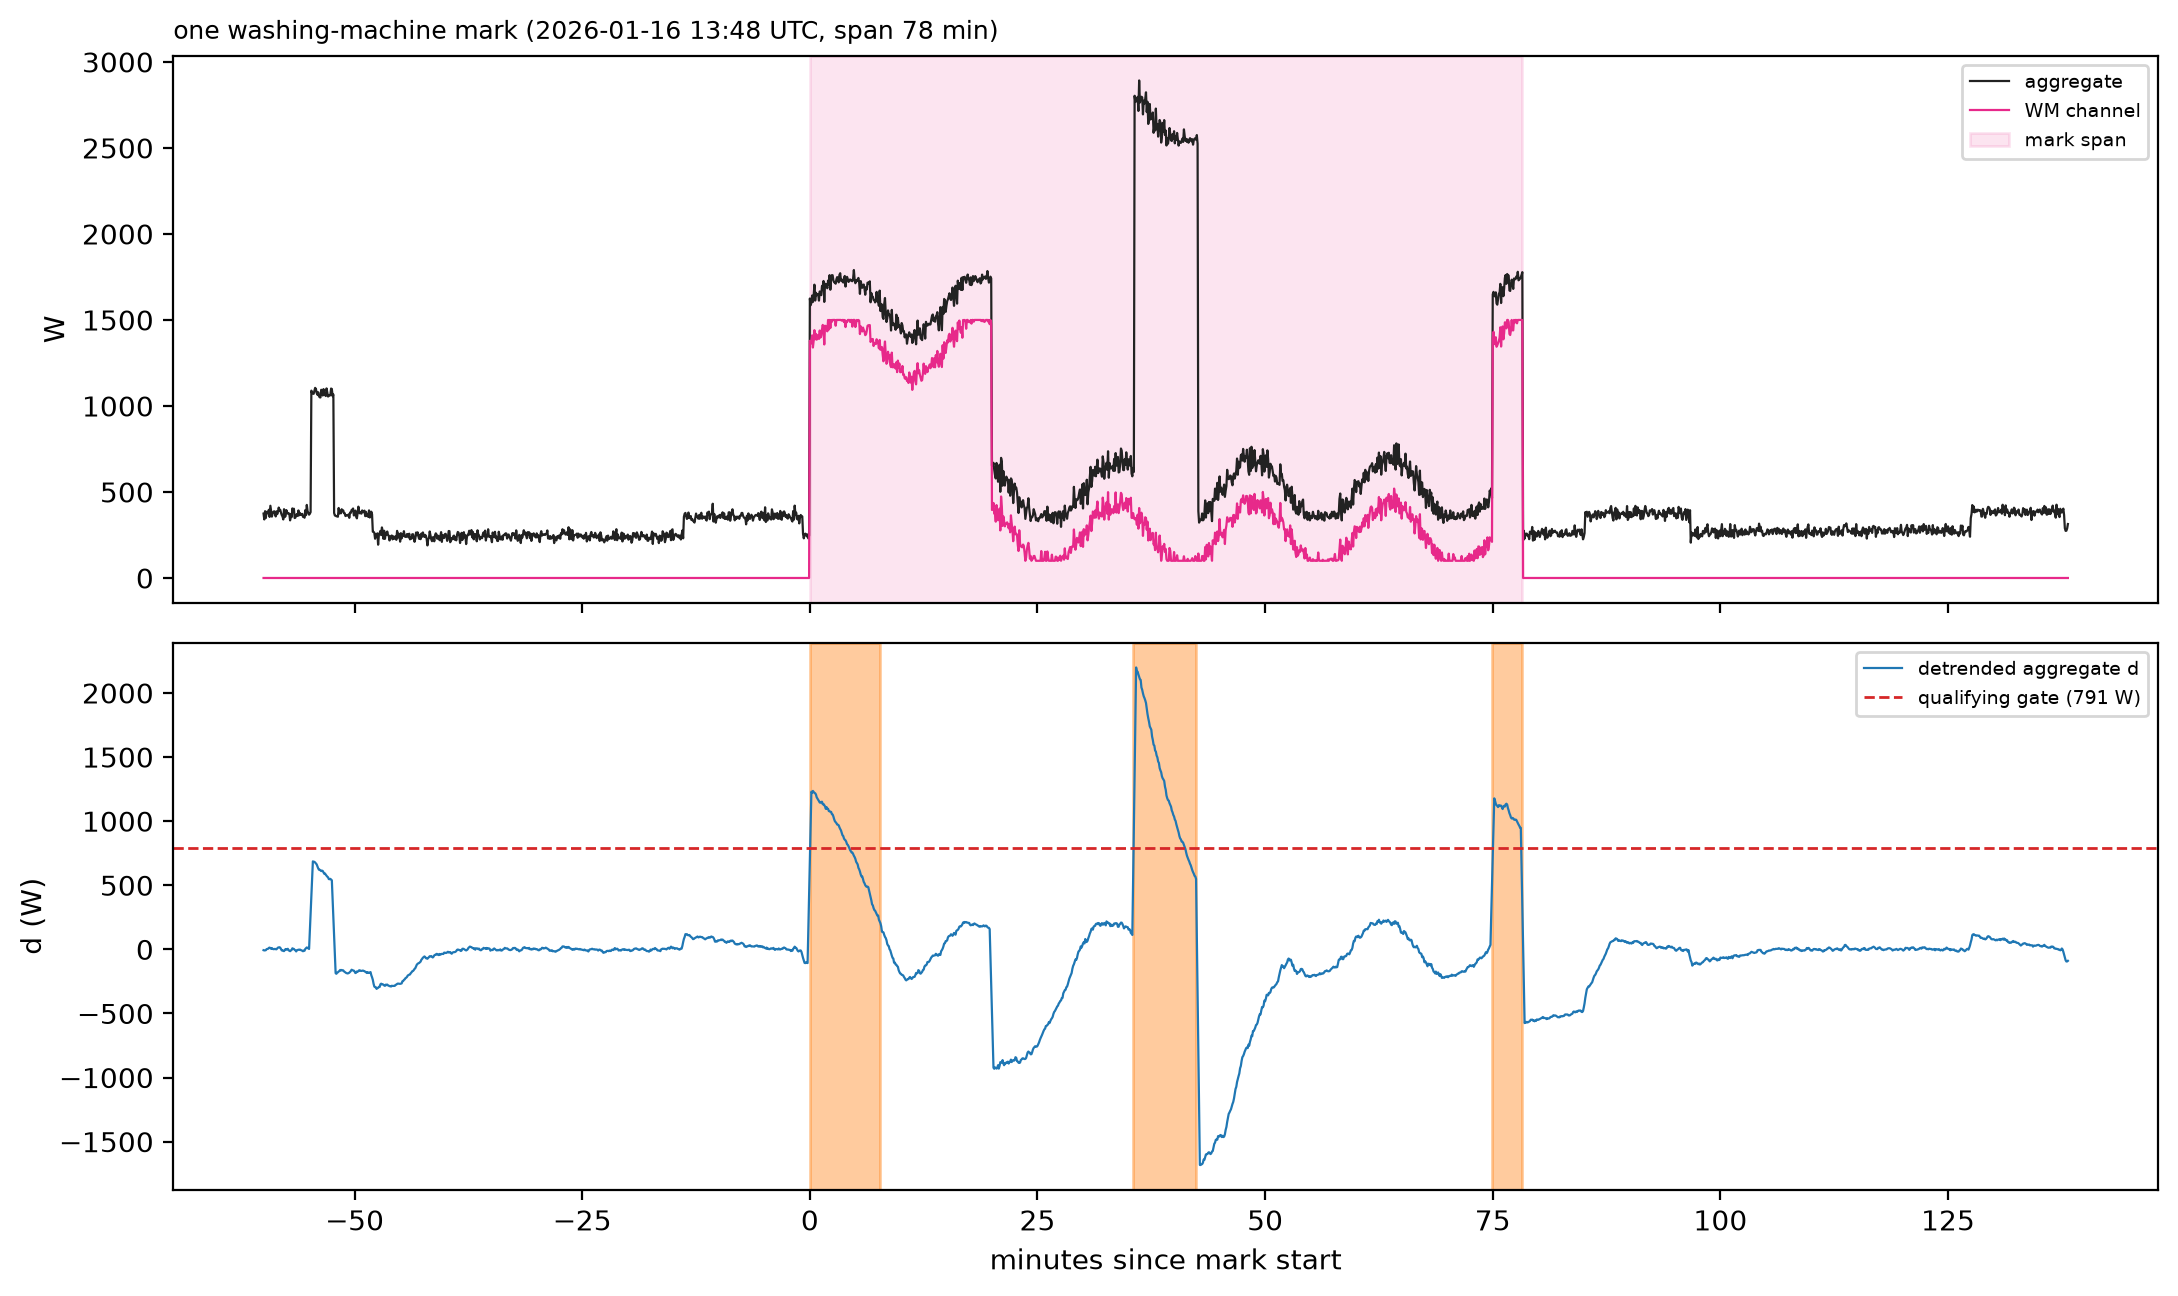

In [ ]:
# --- Anatomy of one program cycle (figure) ------------------------------
# The first test-span washing-machine mark: aggregate + WM channel
# above, detrended aggregate + qualifying-activation shading below.
# This is the picture behind the WM detection result: one strong heater
# activation inside 80+ quiet minutes.
_gt = [e for e in marks["washing_machine"] if e[0] >= split_us]
_a, _b = _gt[0]
_pad = 3_600_000_000  # 1 h of context
_lo, _hi = _a - _pad, _b + _pad
_i0, _i1 = int(np.searchsorted(tsu, _lo)), int(np.searchsorted(tsu, _hi))
_tmin = (tsu[_i0:_i1] - _a) / 6e7  # epoch us -> minutes
_gate = cfg["det_thr_frac"] * profiles["washing_machine"]["dp_peak_w"]
fig_cycle, _axes = plt.subplots(2, 1, figsize=(11, 6.6), sharex=True)
_ax = _axes[0]
_ax.plot(_tmin, w[_i0:_i1], color="#222222", lw=0.8, label="aggregate")
_ax.plot(_tmin, ch["washing_machine"][_i0:_i1], color="#e7298a", lw=0.8, label="WM channel")
_ax.axvspan(0.0, (_b - _a) / 6e7, color="#e7298a", alpha=0.12, label="mark span")
_ax.set_ylabel("W")
_ax.set_title(
    "one washing-machine mark ("
    + f"{pd.to_datetime(_a, unit='us'):%Y-%m-%d %H:%M} UTC, span {(_b - _a) / 6e7:.0f} min)",
    fontsize=9,
    loc="left",
)
_ax.legend(fontsize=7, loc="upper right")
_ax2 = _axes[1]
_ax2.plot(_tmin, d[_i0:_i1], color="#1f77b4", lw=0.8, label="detrended aggregate d")
_ax2.axhline(_gate, color="#d62728", ls="--", lw=1.0, label=f"qualifying gate ({_gate:.0f} W)")
for _r in runfeat:
    if _r[0] >= _lo and _r[1] <= _hi and _r[2] >= _gate:
        _ax2.axvspan((_r[0] - _a) / 6e7, (_r[1] - _a) / 6e7, color="#ff7f0e", alpha=0.4)
_ax2.set_ylabel("d (W)")
_ax2.set_xlabel("minutes since mark start")
_ax2.legend(fontsize=7, loc="upper right")
fig_cycle.tight_layout()
fig_cycle  # noqa: B018  (render figure as cell output)

In [ ]:
# --- Matcher variants + scoring (computation) ---------------------------
def _score(gt, cands):
    pairs = []
    for _gi, (_ga, _gb) in enumerate(gt):
        _ovmin = min(cfg["ov_min_s"], cfg["ov_frac"] * (_gb - _ga) / 1e6)
        for _ci, (_ca, _cb) in enumerate(cands):
            _ov = (min(_gb, _cb) - max(_ga, _ca)) / 1e6
            if _ov >= _ovmin:
                pairs.append((_ov, _gi, _ci))
    pairs.sort(reverse=True)
    _mg, _mc = set(), set()
    for _ov, _gi, _ci in pairs:
        if _gi in _mg or _ci in _mc:
            continue
        _mg.add(_gi)
        _mc.add(_ci)
    _p = len(_mc) / max(1, len(cands))
    _r = len(_mg) / max(1, len(gt))
    return {
        "gt": len(gt),
        "cand": len(cands),
        "matched": len(_mc),
        "p": _p,
        "r": _r,
        "f1": 2 * _p * _r / max(1e-9, _p + _r),
        "cand_idx": _mc,
    }

def _single(n, hi_frac):
    _pdp = profiles[n]["dp_peak_w"]
    _pdur = profiles[n]["dur_s"]
    return [
        (r[0], r[1])
        for r in runfeat
        if r[0] >= split_us
        and cfg["det_thr_frac"] * _pdp <= r[2] <= hi_frac * _pdp
        and cfg["det_dur_lo"] * _pdur <= r[3] <= cfg["det_dur_hi"] * _pdur
    ]

def _chain(n):
    _pdp = profiles[n]["dp_peak_w"]
    _pdur = profiles[n]["dur_s"]
    _out = []
    for _r in runfeat:
        if _r[0] < split_us or _r[2] < cfg["det_thr_frac"] * _pdp:
            continue
        if _out and (_r[0] - _out[-1][1]) / 1e6 <= cfg["chain_gap_s"]:
            _out[-1] = (_out[-1][0], _r[1])
        else:
            _out.append((_r[0], _r[1]))
    return [
        (_a, _b) for _a, _b in _out if cfg["det_dur_lo"] * _pdur <= (_b - _a) / 1e6 <= cfg["det_dur_hi"] * _pdur
    ]

def _anchor(n):
    _pdp = profiles[n]["dp_peak_w"]
    _pdur = profiles[n]["dur_s"]
    _pre = int(cfg["anchor_pre_frac"] * _pdur * 1e6)
    _merge = int(cfg["anchor_merge_frac"] * _pdur * 1e6)
    _q = [
        _r
        for _r in runfeat
        if _r[0] >= split_us and cfg["det_thr_frac"] * _pdp <= _r[2] <= cfg["anchor_band_hi_frac"] * _pdp
    ]
    _wins = sorted((_r[0] - _pre, _r[0] - _pre + int(_pdur * 1e6), _r) for _r in _q)
    _merged = []
    for _a, _b, _r in _wins:
        if _merged and _a <= _merged[-1][1] - _merge:
            _merged[-1] = (_merged[-1][0], max(_merged[-1][1], _b), _merged[-1][2])
        else:
            _merged.append((_a, _b, _r))
    return _merged

_test = {n: [e for e in marks[n] if e[0] >= split_us] for n in sorted(marks)}
_burst = cfg["burst"]
_prog = cfg["program"]
res_a = {}
res_b = {}
for _n in _burst + _prog:
    _gt = _test[_n]
    if _n in _burst:
        res_a[_n] = _score(_gt, _single(_n, 1e9))
        res_b[_n] = _score(_gt, _single(_n, cfg["band_hi_frac"]))
    else:
        res_a[_n] = _score(_gt, _chain(_n))
        res_b[_n] = res_a[_n]
_merged = _anchor(_prog[0])
res_c = {_prog[0]: _score(_test[_prog[0]], [(_a, _b) for _a, _b, _ in _merged])}
# false anchored windows: which device owns the anchor run? nearest
# burst profile in z-scored (dP, dur) space.
_pool = np.array([[profiles[n]["dp_peak_w"], profiles[n]["dur_s"]] for n in _burst])
_mu = _pool.mean(axis=0)
_sd = _pool.std(axis=0)
_pzn = (_pool - _mu) / _sd
_false_owners = {n: 0 for n in _burst}
for _ci, (_a, _b, _r) in enumerate(_merged):
    if _ci not in res_c[_prog[0]]["cand_idx"]:
        _v = (np.array([_r[2], _r[3]]) - _mu) / _sd
        _false_owners[_burst[int(np.argmin(np.abs(_pzn - _v).sum(axis=1)))]] += 1
# ceiling: does every test cycle contain a qualifying activation? (the
# activation signal is present; attribution is a separate question)
ceiling = {}
for _n in _burst + _prog:
    _pdp = profiles[_n]["dp_peak_w"]
    _hit = 0
    for _a, _b in _test[_n]:
        if any(_r[2] >= cfg["det_thr_frac"] * _pdp and _r[1] >= _a and _r[0] <= _b for _r in runfeat):
            _hit += 1
    ceiling[_n] = {"n": len(_test[_n]), "hit": _hit}
# miss anatomy for the program device under scalar matching (runs that
# overlap the mark - the centered smoother leads the channel edge by a
# couple of samples, so run starts sit just before mark starts)
_pdp = profiles[_prog[0]]["dp_peak_w"]
_miss_n = [
    len([_r for _r in runfeat if _r[1] >= _a and _r[0] <= _b and _r[2] >= cfg["det_thr_frac"] * _pdp])
    for _a, _b in _test[_prog[0]]
]
miss_anatomy = {
    "n_test": len(_test[_prog[0]]),
    "with_qual": int(sum(1 for _k in _miss_n if _k >= 1)),
    "n_qual_p50": float(np.median(_miss_n)),
    "n_qual_max": int(max(_miss_n)),
}
det = {
    "run_stats": run_stats,
    "A": res_a,
    "B": res_b,
    "C": res_c,
    "false_owners": _false_owners,
    "ceiling": ceiling,
    "miss_anatomy": miss_anatomy,
}

In [ ]:
# presentation: detection tables
def _rows(res):
    _out = []
    for _n in ("kettle", "microwave", "washing_machine"):
        if _n not in res:
            continue
        _r = res[_n]
        _out.append(
            [
                _n,
                _r["gt"],
                _r["cand"],
                _r["matched"],
                f"{_r['p']:.2f}",
                f"{_r['r']:.2f}",
                f"{_r['f1']:.2f}",
            ]
        )
    return _out

_heads = ["device", "GT", "cand", "matched", "P", "R", "F1"]
_ta = bl.md_table(_heads, _rows(det["A"]))
_tb = bl.md_table(_heads, _rows(det["B"]))
_tc = bl.md_table(_heads, _rows(det["C"]))
_ceil = bl.md_table(
    ["device", "test cycles", "with a qualifying activation"],
    [[_n, det["ceiling"][_n]["n"], det["ceiling"][_n]["hit"]] for _n in ("kettle", "microwave", "washing_machine")],
)
_rs = det["run_stats"]
_miss = det["miss_anatomy"]
_own = " / ".join(f"{_k} {_v}" for _k, _v in det["false_owners"].items())
mo.md(
    "## Detection (measured, test span: last 15 days)\n\n"
    + f"Runs vocabulary: {_rs['n']} runs ({_rs['n_cal']} cal / {_rs['n_test']} test), "
    + f"duration p50 {_rs['dur_p50_s']:.0f} s, p90 {_rs['dur_p90_s']:.0f} s, "
    + f"max {_rs['dur_max_s']:.0f} s - event-sized, no base-template contamination.\n\n"
    + "**A. per-device lower gate (UK-DALE mirror)**\n\n"
    + _ta
    + "\n\n**B. band gate (bursts; program unchanged)**\n\n"
    + _tb
    + "\n\n**C. anchored cycle windows (program device)**\n\n"
    + _tc
    + "\n\nUnmatched anchored windows are spawned by other devices' "
    + f"activations inside the same dP band: {_own}.\n\n"
    + "**Ceiling - signal presence per test cycle**\n\n"
    + _ceil
    + "\n\nUnder scalar matching the missed WM cycles are not silent: "
    + f"{_miss['with_qual']} of {_miss['n_test']} contain a qualifying "
    + f"activation (median {_miss['n_qual_p50']:.0f} per cycle) - the "
    + "activation is present; the scalar profile cannot own it."
)

## Detection (measured, test span: last 15 days)

Runs vocabulary: 315 runs (164 cal / 151 test), duration p50 285 s, p90 455 s, max 680 s - event-sized, no base-template contamination.

**A. per-device lower gate (UK-DALE mirror)**

| device | GT | cand | matched | P | R | F1 |
|---|---|---|---|---|---|---|
| kettle | 84 | 101 | 80 | 0.79 | 0.95 | 0.86 |
| microwave | 55 | 133 | 49 | 0.37 | 0.89 | 0.52 |
| washing_machine | 13 | 3 | 0 | 0.00 | 0.00 | 0.00 |

**B. band gate (bursts; program unchanged)**

| device | GT | cand | matched | P | R | F1 |
|---|---|---|---|---|---|---|
| kettle | 84 | 100 | 79 | 0.79 | 0.94 | 0.86 |
| microwave | 55 | 55 | 47 | 0.85 | 0.85 | 0.85 |
| washing_machine | 13 | 3 | 0 | 0.00 | 0.00 | 0.00 |

**C. anchored cycle windows (program device)**

| device | GT | cand | matched | P | R | F1 |
|---|---|---|---|---|---|---|
| washing_machine | 13 | 52 | 13 | 0.25 | 1.00 | 0.40 |

Unmatched anchored windows are spawned by other devices' activations inside the same dP band: kettle 15 / microwave 24.

**Ceiling - signal presence per test cycle**

| device | test cycles | with a qualifying activation |
|---|---|---|
| kettle | 84 | 82 |
| microwave | 55 | 51 |
| washing_machine | 13 | 12 |

Under scalar matching the missed WM cycles are not silent: 12 of 13 contain a qualifying activation (median 2 per cycle) - the activation is present; the scalar profile cannot own it.

## Findings

1. **The annotations are correct cycle marks - yes, by construction.**
   Flag-to-channel consistency is exact (every OFF row 0.00 W, every ON
   row positive); kettle/microwave marks are the bursts themselves; the
   27 washing-machine marks are single coherent blocks (p50 about
   82 min) with between-cycle gaps of many hours and zero sub-60-s
   gaps - no fragmentation, no curation needed (and none performed,
   per scope).
2. **The aggregate is an idealized substrate.** Base template + 4
   channels, exactly (max unexplained smoothed step about 16 W at
   steps >= 100 W); zero unlabelled loads; low simultaneity. No real
   home will ever be this clean - read everything below as an upper
   bound.
3. **Onsets are detectable here** (detrended onset steps p50 about
   1890/880/1320 W for kettle/microwave/WM) - the UK-DALE quiet-onset
   pathology (WM onset about 4 W) is absent by construction, so the
   runs vocabulary applies directly.
4. **Identification: marks identify their device.** LOO about 0.95
   (159 calibration marks) vs 0.79 on UK-DALE; the residual
   kettle-vs-microwave confusion is the same scalar-feature limit.
5. **Disaggregation: bursts yes, program no.** With the band gate,
   kettle F1 about 0.86 and microwave about 0.85 (UK-DALE: 0.11/0.08) -
   the UK-DALE burst failure was data dirt, not method. The washing
   machine scores 0.00 under scalar matching even here: 12 of the 13
   test cycles contain a qualifying activation (kettle 82/84,
   microwave 51/55), but the program cycle's aggregate expression is
   one heater activation inside 80+ quiet minutes, and the 82-min
   cycle duration has no counterpart in the runs vocabulary
   (dur-window rejection).
6. **The anchored-window probe separates recall from attribution:**
   R 1.00 at P 0.25 - the activation is there in 12 of 13 cycles;
   owning it is not (kettle/microwave activations inside the same dP
   band spawn 39 false anchors). The verdict mirrors the UK-DALE
   render, now with the dirt removed: scalar (dP, dur) profiles cannot
   represent program cycles.
   The richer-profile direction (within-cycle rhythm, anchored
   matching, assignment) is required before the human-annotation
   campaign (H13) can pay off. The synthetic marks validate the flow's
   machinery, not the product claim.

Companion renders: the UK-DALE flow on dirty reality is
docs/reports/gt_cycle/01_ukdale_gt_cycle_eda.ipynb; the manual-curation
question it motivates is H13 (docs/hypotheses/). The synthetic dataset
is read-only client material under repo/ (forensics:
deprecated/analysis/repo-forensics/). Nothing in this notebook is a gate or a
decision - provisional evidence only.